![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)

# Laboratory 3. Circuits and Compact Models

 ## 0.1 Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm

import logging
import sys
from functools import partial
from pprint import pprint

import gdsfactory as gf
import jax
import jax.example_libraries.optimizers as opt
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
from gdsfactory.generic_tech import get_generic_pdk
from numpy.fft import fft2, fftfreq, fftshift, ifft2
from rich.logging import RichHandler
from scipy import constants
from sklearn.linear_model import LinearRegression
from tqdm.notebook import trange
from scipy.constants import c as c0

import gplugins.sax as gs
import gplugins.tidy3d as gt
from gplugins.common.config import PATH

logger = logging.getLogger()
logger.removeHandler(sys.stderr)
logging.basicConfig(level="WARNING", datefmt="[%X]", handlers=[RichHandler()])

/tmp/ipykernel_1017/616826865.py:17: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import get_generic_pdk


## 0.2 Compact Models for simulations

### 0.2.1. Waveguide compact model (Lab1. LO4)

We start from the waveguide's effective index second degree polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Or from the parameters derived from the polynomial coefficients: 
 
$$
n_\mathrm{eff}(\lambda_0) = n_1~ ;~ n_g(\lambda_0) = n_1 - n_2\,\lambda_0~;~ D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

The transmmission through the waveguide should be modeled as: 

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$
With  
$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

We are going to use [SAX](https://pypi.org/project/sax/), a scatter parameter circuit simulator, to implement simulations in the frequency (wavelength) domain. The following cell demonstrates how to define the most basic component transfer function: 

In [2]:
# The model should be a Python function that takes as input the relevant parameters
# (e.g., wavelength, effective index, length, loss) and returns a SAX SDict representing
# the waveguide's S-parameters.
# Parameters:
# wl: Wavelength to simulate (um)
# wl0: Reference wavelength - where you calculated the group index and dispersion (um))
# neff: Effective index at the reference wavelength (au)
# ng: Group index (au)
# length: Length of the waveguide in micrometers (um)
# loss: Propagation loss in dB/um (Experimental value)
# D: Dispersion parameter (s^2/m)
def waveguide(wl=1.55, wl0=1.55, neff=1.6072, ng=2.0, length=10.0, loss=0.0, D=0) -> sax.SDict:
    dwl = wl - wl0
    n1 = neff
    n2 = (n1-ng)/wl0
    n3 = -D*c0/(2*wl0)
    neff = n1 + n2*dwl + n3*dwl**2
    phase = 2 * jnp.pi * neff * length / wl
    transmission = 10 ** (-loss * length / 20) * jnp.exp(1j * phase)
    wg_dict = sax.reciprocal(
        {
            ("in0", "out0"): transmission,
        }
    )
    return wg_dict

### 0.2.2. Coupler compact model (Lab2 LO6)

We can start with the ideal coupler transfer function. You can then update your model with the parameters you found in your Laboratory 2. The model we are going to implement does not take into account if the coupler is an MMI or a Directional Coupler, it just use as parameters the coupling coefficient to calculate the output power at each port. 

$$
\begin{pmatrix}
E_{o1}\\
E_{o2}
\end{pmatrix}
=
\begin{pmatrix}
\sqrt{1-K} & -\mathrm{j}\sqrt{K}\\
-\mathrm{j}\sqrt{K} & \sqrt{1-K}
\end{pmatrix}
\begin{pmatrix}
E_{i1}\\
E_{i2}
\end{pmatrix}
$$

In [3]:
# Coupler Model
# We define again the Python function for the coupler compact model.
# Parameters:
# coupling: Coupling coefficient (between 0 and 1)
# You MUST update the model with the parameters you found in your Laboratory 2: 
# Excess loss, actual phase shift.
def coupler(coupling=0.5) -> sax.SDict:
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    # The coupler is a reciprocal device, so we use sax.reciprocal to create the SDict
    # (reciprocal device means it behaves the same way in both directions)
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict


## LO.1. Mach - Zehnder Interferometer

### 1.1. MZI Circuit Model

Using SAX library, we can now define the components, connections and models needed to build our circuit. Let's start with the MZI: 

<img src="mzi.png" alt="mzi circuit" width="600">

We will need two couplers and two waveguides: 


In [4]:
# MZI Circuit
# We will define instances, connections and ports for the MZI circuit using the SAX library.
# We will use the coupler and waveguide models defined above.
mzi, info = sax.circuit(
    netlist={
        # Define instances of couplers and waveguides
        "instances": {
            "coup_E": "coupler",
            "wvg_N": "waveguide",
            "wvg_S": "waveguide",
            "coup_W": "coupler",
        },
        # Define connections between the instances
        "connections": {
            "coup_E,out0": "wvg_S,in0",
            "wvg_S,out0": "coup_W,in0",
            "coup_E,out1": "wvg_N,in0",
            "wvg_N,out0": "coup_W,in1",
        },
        # Define the external ports of the MZI circuit
        "ports": {
            "in0": "coup_E,in0",
            "in1": "coup_E,in1",
            "out0": "coup_W,out0",
            "out1": "coup_W,out1",
        },
    },
    # Important! Provide here the models for the components used in the circuit
    # Here we use the coupler and waveguide functions defined above
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)


[16:41:09] WARNING  WARNING:jax._src.xla_bridge:An NVIDIA GPU may be present on this machine, but ]8;id=707318;file:///home/mella/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py\xla_bridge.py]8;;\:]8;id=589584;file:///home/mella/cifoin-lab3/.venv/lib/python3.12/site-packages/jax/_src/xla_bridge.py#864\864]8;;\
                    a CUDA-enabled jaxlib is not installed. Falling back to cpu.                                   

Using this circuit model, it is possible now to perform simulations to obtain the MZI response:

Text(0, 0.5, '|H|^2 [dB]')

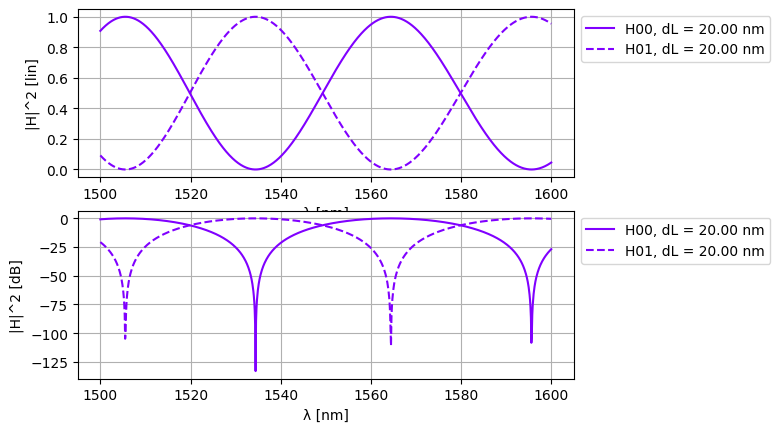

In [5]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 1000)

# Length values to simulate. We have a base length and we will vary the length of one arm using delta_l_v
delta_l_v = np.array([20,]) 
l_base = 10.0

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    # We can access the waveguide lengths by using the instance names defined in the circuit
    # First we instantiate the MZI with the desired lengths
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    # Then we can extract the S-parameters using the port names defined in the circuit
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

The resulting interference pattern allows us to determine the **free spectral range** (FSR). By locating two adjacent notches in the transfer function, the difference between their wavelengths gives the FSR, which satisfies:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,\Delta L}
$$

You can use this code section with certain variations for LO1a,1b,2 and 3.

LO.1.A Perfectly balanced MZI

<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1017/1783940502.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/1783940502.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/1783940502.py:30: SyntaxWarning: invalid escape sequence '\m'
  ax[1].plot(wl * 1e3

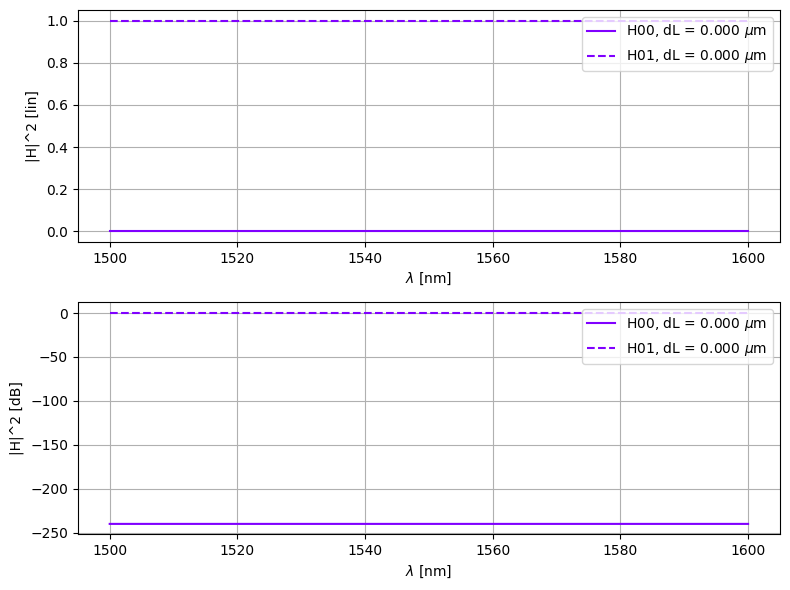

In [6]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 1000)

# Para el MZI perfectamente balanceado, dL = 0
delta_l_v = np.array([0.0,]) 
l_base = 10.0

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1, figsize=(8, 6))
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    
    # Extract S-parameters
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    # Añadimos + 1e-12 para evitar el warning de log10(0)
    H00_dB = 20.0*jnp.log10(np.abs(H00) + 1e-12)
    H01_dB = 20.0*jnp.log10(np.abs(H01) + 1e-12)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.3f} $\mu$m")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.3f} $\mu$m")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.3f} $\mu$m")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.3f} $\mu$m")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("$\lambda$ [nm]")
    ax[i].legend(loc='upper right', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")
plt.tight_layout()
plt.show()

LO.1.B Unbalanced MZI

<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\l'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:29: SyntaxWarning: invalid escape sequence '\m'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:32: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1017/1807645637.py:28: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} $\mu$m")
/tmp/ipykernel_1017/1807645637.py:29: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} $\mu$m")
/tmp/ipykernel_1017/1807645637.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax[1].plot(wl * 1e3

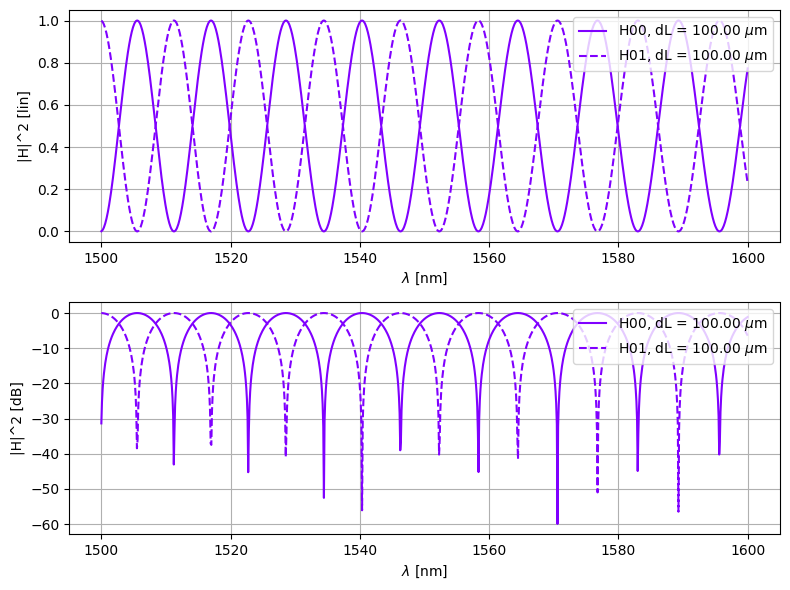

In [7]:
# Wavelengths to simulate [1500-1600] nm
# Un paso de 0.001 um (1 nm) entre 1.50 y 1.60 um equivale a unos 100 puntos, 
# pero podemos dejar 1000 puntos para que la gráfica quede súper suave.
wl = jnp.linspace(1.50, 1.60, 1000)

# Length values to simulate. HINT explícito: dL = 100 um
delta_l_v = np.array([100.0]) 
l_base = 10.0

# Testbench
mzi_test = []

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1, figsize=(8, 6))
for i, delta_l in enumerate(delta_l_v):
    # Simulate MZI with given length difference
    mzi_test = mzi(wl=wl, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
    
    # Extract S-parameters
    H00 = mzi_test["in0", "out0"]
    H01 = mzi_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) + 1e-12)
    H01_dB = 20.0*jnp.log10(np.abs(H01) + 1e-12)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} $\mu$m")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} $\mu$m")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} $\mu$m")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} $\mu$m")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("$\lambda$ [nm]")
    ax[i].legend(loc='upper right', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")
plt.tight_layout()
plt.show()

LO.2 MZI Design


<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:39: SyntaxWarning: invalid escape sequence '\l'
<>:48: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1017/2405870708.py:31: SyntaxWarning: invalid escape sequence '\m'
  ax[0, 0].plot(wl_full * 1e3, np.abs(H00_full)**2, linestyle="-", color='purple', label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/2405870708.py:36: SyntaxWarning: invalid escape sequence '\m'
  ax[1, 0].plot(wl_full * 1e3, H00_dB_full, linestyle="-", color='purple', label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/2405870708.py:39: SyntaxWarning: invalid escape sequence '\l'
  ax[1, 0].set_xlabel("$\lambda$ [nm]")
/tmp/ipykernel_1017/2405870708.py:48: SyntaxWarning: invalid escap

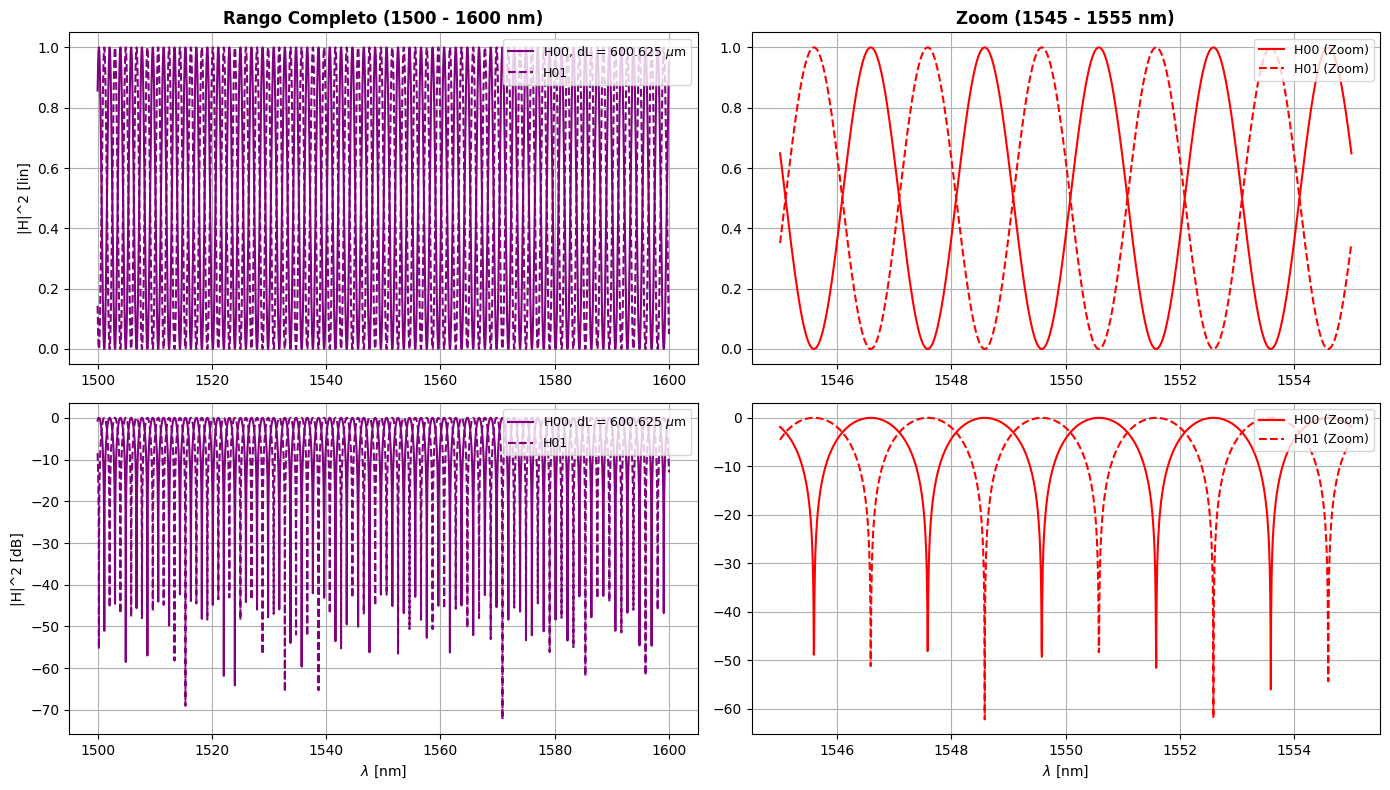

In [8]:
# MZI Desbalanceado (FSR = 2 nm) - Rango Completo y Zoom

# 1. Rango completo [1500-1600] nm (10000 puntos para resolución)
wl_full = jnp.linspace(1.50, 1.60, 10000)

# 2. Rango con zoom [1545-1555] nm (10 nm de ventana para ver 5 ciclos claros)
wl_zoom = jnp.linspace(1.545, 1.555, 2000)

# Diferencia de longitud calculada para FSR = 2 nm
delta_l = 600.625
l_base = 10.0

# Simular MZI para rango completo
mzi_full = mzi(wl=wl_full, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
H00_full = mzi_full["in0", "out0"]
H01_full = mzi_full["in0", "out1"]
H00_dB_full = 20.0*jnp.log10(np.abs(H00_full) + 1e-12)
H01_dB_full = 20.0*jnp.log10(np.abs(H01_full) + 1e-12)

# Simular MZI para rango con zoom
mzi_zoom = mzi(wl=wl_zoom, wvg_S={"length": l_base}, wvg_N={"length": l_base+delta_l})
H00_zoom = mzi_zoom["in0", "out0"]
H01_zoom = mzi_zoom["in0", "out1"]
H00_dB_zoom = 20.0*jnp.log10(np.abs(H00_zoom) + 1e-12)
H01_dB_zoom = 20.0*jnp.log10(np.abs(H01_zoom) + 1e-12)

# Crear figura con 4 subgráficas (2 filas x 2 columnas)
fig, ax = plt.subplots(2, 2, figsize=(14, 8))

# ---- COLUMNA IZQUIERDA (Rango Completo) ----
ax[0, 0].plot(wl_full * 1e3, np.abs(H00_full)**2, linestyle="-", color='purple', label=f"H00, dL = {delta_l:.3f} $\mu$m")
ax[0, 0].plot(wl_full * 1e3, np.abs(H01_full)**2, linestyle="--", color='purple', label=f"H01")
ax[0, 0].set_title("Rango Completo (1500 - 1600 nm)", fontweight='bold')
ax[0, 0].set_ylabel("|H|^2 [lin]")

ax[1, 0].plot(wl_full * 1e3, H00_dB_full, linestyle="-", color='purple', label=f"H00, dL = {delta_l:.3f} $\mu$m")
ax[1, 0].plot(wl_full * 1e3, H01_dB_full, linestyle="--", color='purple', label=f"H01")
ax[1, 0].set_ylabel("|H|^2 [dB]")
ax[1, 0].set_xlabel("$\lambda$ [nm]")

# ---- COLUMNA DERECHA (Zoom) ----
ax[0, 1].plot(wl_zoom * 1e3, np.abs(H00_zoom)**2, linestyle="-", color='red', label=f"H00 (Zoom)")
ax[0, 1].plot(wl_zoom * 1e3, np.abs(H01_zoom)**2, linestyle="--", color='red', label=f"H01 (Zoom)")
ax[0, 1].set_title("Zoom (1545 - 1555 nm)", fontweight='bold')

ax[1, 1].plot(wl_zoom * 1e3, H00_dB_zoom, linestyle="-", color='red', label=f"H00 (Zoom)")
ax[1, 1].plot(wl_zoom * 1e3, H01_dB_zoom, linestyle="--", color='red', label=f"H01 (Zoom)")
ax[1, 1].set_xlabel("$\lambda$ [nm]")

# Formato común para todas las gráficas
for i in range(2):
    for j in range(2):
        ax[i, j].grid(visible=True)
        ax[i, j].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

LO.3 Delay imbalance with loss


CASE 1: Simulate for Ka = Kb = 0.5 for all wvl

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1017/2752540586.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wvl * 1e3, np.abs(H00_sim)**2, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/2752540586.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[1].plot(wvl * 1e3, H00_dB_sim, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/2752540586.py:43: SyntaxWarning: invalid escape sequence '\l'
  ax[1].set_xlabel("$\lambda$ [nm]")


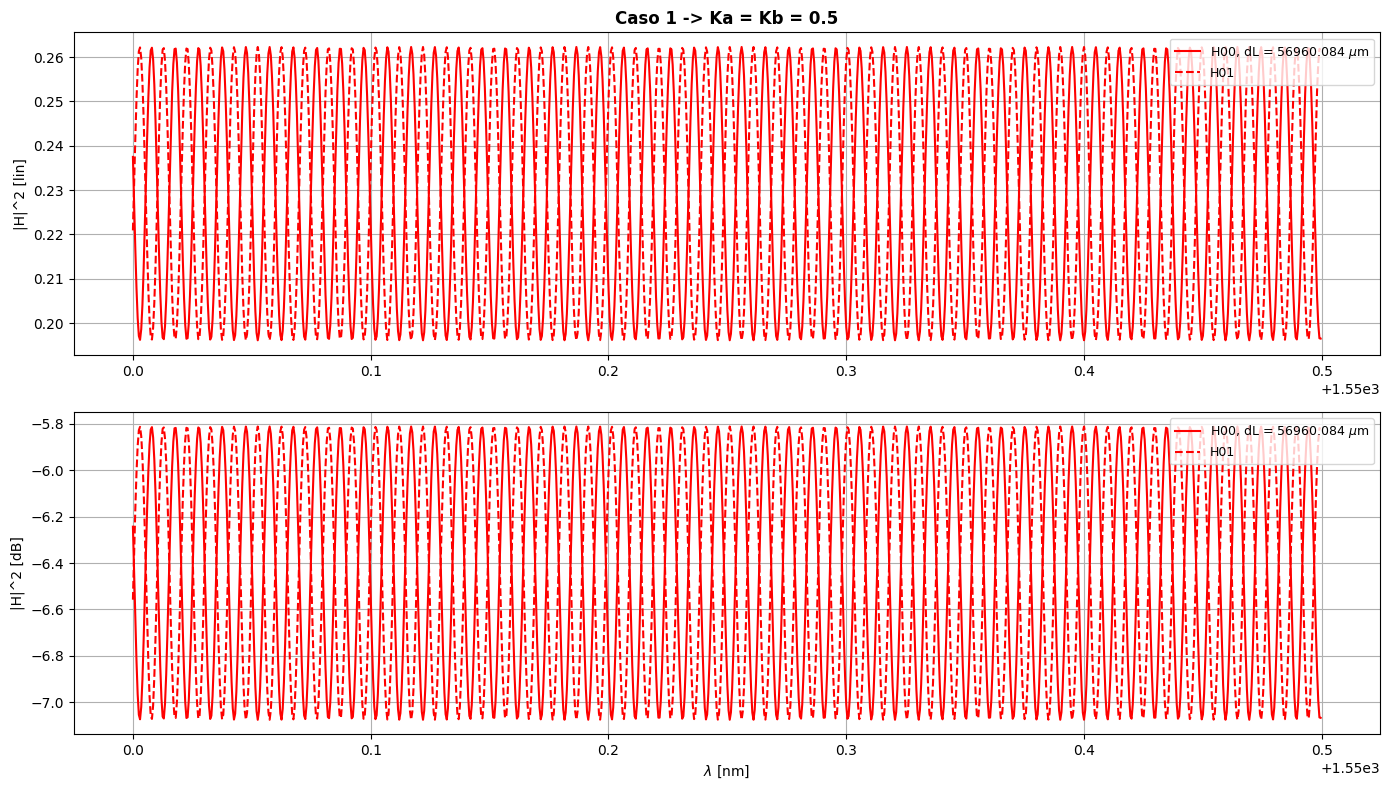

El ER del CASO 2 es: 1.26 dB


In [9]:
# 1. Vector de longitudes de onda en el rango de: [1550-1550.5] nm (con saltos de 0.0000005)
wvl = jnp.arange(1.55, 1.5505, 0.0000005)

l_base = 1000.0
delta_l = l_base + 55960.0840224255 

config_wvg_comun = {
    "neff": 2.38,
    "ng": 4.25,
    "D": 0,
    "loss": 4e-4 # 4 dB/cm en dB/um
}

# Simular MZI para todo el vector wvl
mzi_sim = mzi(
    wl = wvl, 
    coup_E = {"coupling": 0.5},
    coup_W = {"coupling": 0.5},
    wvg_S = {"length": l_base, **config_wvg_comun}, 
    wvg_N = {"length": l_base+delta_l, **config_wvg_comun}
)


H00_sim = mzi_sim["in0", "out0"]
H01_sim = mzi_sim["in0", "out1"]
H00_dB_sim = 20.0*jnp.log10(np.abs(H00_sim) + 1e-12)
H01_dB_sim = 20.0*jnp.log10(np.abs(H01_sim) + 1e-12)

# Crear figura con 2 subgráficas (2 filas x 1 columnas)
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

# ------- Fila 0: Escala lineal ------- #
ax[0].plot(wvl * 1e3, np.abs(H00_sim)**2, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
ax[0].plot(wvl * 1e3, np.abs(H01_sim)**2, linestyle="--", color='red', label=f"H01")
ax[0].set_title("Caso 1 -> Ka = Kb = 0.5", fontweight='bold')
ax[0].set_ylabel("|H|^2 [lin]")


# ------- Fila 1: En dB ------- #
ax[1].plot(wvl * 1e3, H00_dB_sim, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
ax[1].plot(wvl * 1e3, H01_dB_sim, linestyle="--", color='red', label=f"H01")
ax[1].set_ylabel("|H|^2 [dB]")
ax[1].set_xlabel("$\lambda$ [nm]")

# Formato común para todas las gráficas
for i in range(2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()


H00_dB_numpy = np.array(H00_dB_sim)

ER = np.max(H00_dB_numpy) - np.min(H00_dB_numpy)
print(f"El ER del CASO 2 es: {ER:.2f} dB")

CASE 2: Simulate for Ka=0.1 for all wvl Kb=0.5 for all wvl

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1017/817271028.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wvl * 1e3, np.abs(H00_sim)**2, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/817271028.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[1].plot(wvl * 1e3, H00_dB_sim, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/817271028.py:43: SyntaxWarning: invalid escape sequence '\l'
  ax[1].set_xlabel("$\lambda$ [nm]")


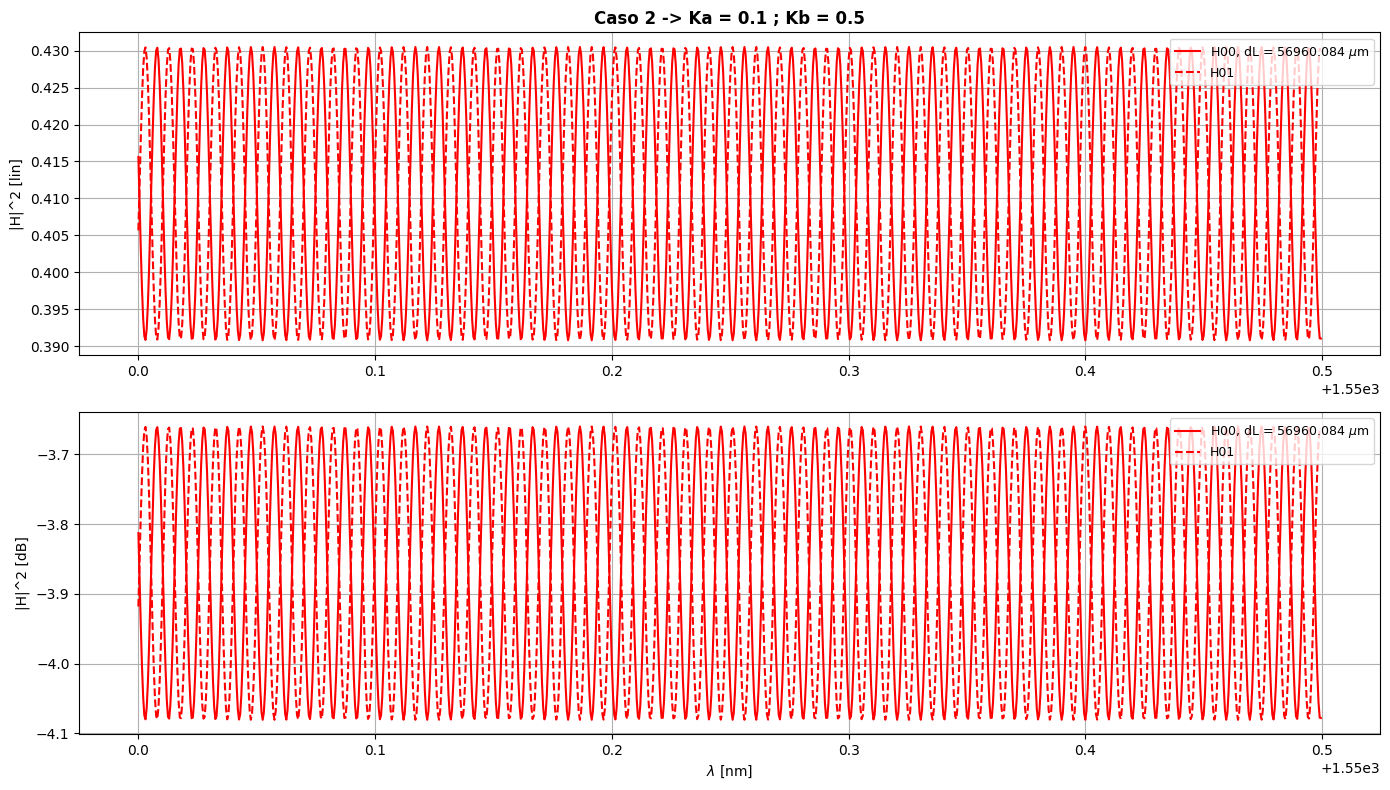

El ER del CASO 2 es: 0.42 dB


In [10]:
# 1. Vector de longitudes de onda en el rango de: [1550-1550.5] nm (con saltos de 0.0000005)
wvl = jnp.arange(1.55, 1.5505, 0.0000005)

l_base = 1000.0
delta_l = l_base + 55960.0840224255 

config_wvg_comun = {
    "neff": 2.38,
    "ng": 4.25,
    "D": 0,
    "loss": 4e-4 # 4 dB/cm en dB/um
}

# Simular MZI para todo el vector wvl
mzi_sim = mzi(
    wl = wvl, 
    coup_E = {"coupling": 0.1},
    coup_W = {"coupling": 0.5},
    wvg_S = {"length": l_base, **config_wvg_comun}, 
    wvg_N = {"length": l_base+delta_l, **config_wvg_comun}
)


H00_sim = mzi_sim["in0", "out0"]
H01_sim = mzi_sim["in0", "out1"]
H00_dB_sim = 20.0*jnp.log10(np.abs(H00_sim) + 1e-12)
H01_dB_sim = 20.0*jnp.log10(np.abs(H01_sim) + 1e-12)

# Crear figura con 2 subgráficas (2 filas x 1 columnas)
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

# ------- Fila 0: Escala lineal ------- #
ax[0].plot(wvl * 1e3, np.abs(H00_sim)**2, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
ax[0].plot(wvl * 1e3, np.abs(H01_sim)**2, linestyle="--", color='red', label=f"H01")
ax[0].set_title("Caso 2 -> Ka = 0.1 ; Kb = 0.5", fontweight='bold')
ax[0].set_ylabel("|H|^2 [lin]")


# ------- Fila 1: En dB ------- #
ax[1].plot(wvl * 1e3, H00_dB_sim, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
ax[1].plot(wvl * 1e3, H01_dB_sim, linestyle="--", color='red', label=f"H01")
ax[1].set_ylabel("|H|^2 [dB]")
ax[1].set_xlabel("$\lambda$ [nm]")

# Formato común para todas las gráficas
for i in range(2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()


H00_dB_numpy = np.array(H00_dB_sim)

ER = np.max(H00_dB_numpy) - np.min(H00_dB_numpy)
print(f"El ER del CASO 2 es: {ER:.2f} dB")

Intento de mejora de la ER (compensación de las pérdidas por la dL demasiado alta)

<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:43: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1017/160236652.py:33: SyntaxWarning: invalid escape sequence '\m'
  ax[0].plot(wvl * 1e3, np.abs(H00_sim)**2, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/160236652.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[1].plot(wvl * 1e3, H00_dB_sim, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
/tmp/ipykernel_1017/160236652.py:43: SyntaxWarning: invalid escape sequence '\l'
  ax[1].set_xlabel("$\lambda$ [nm]")


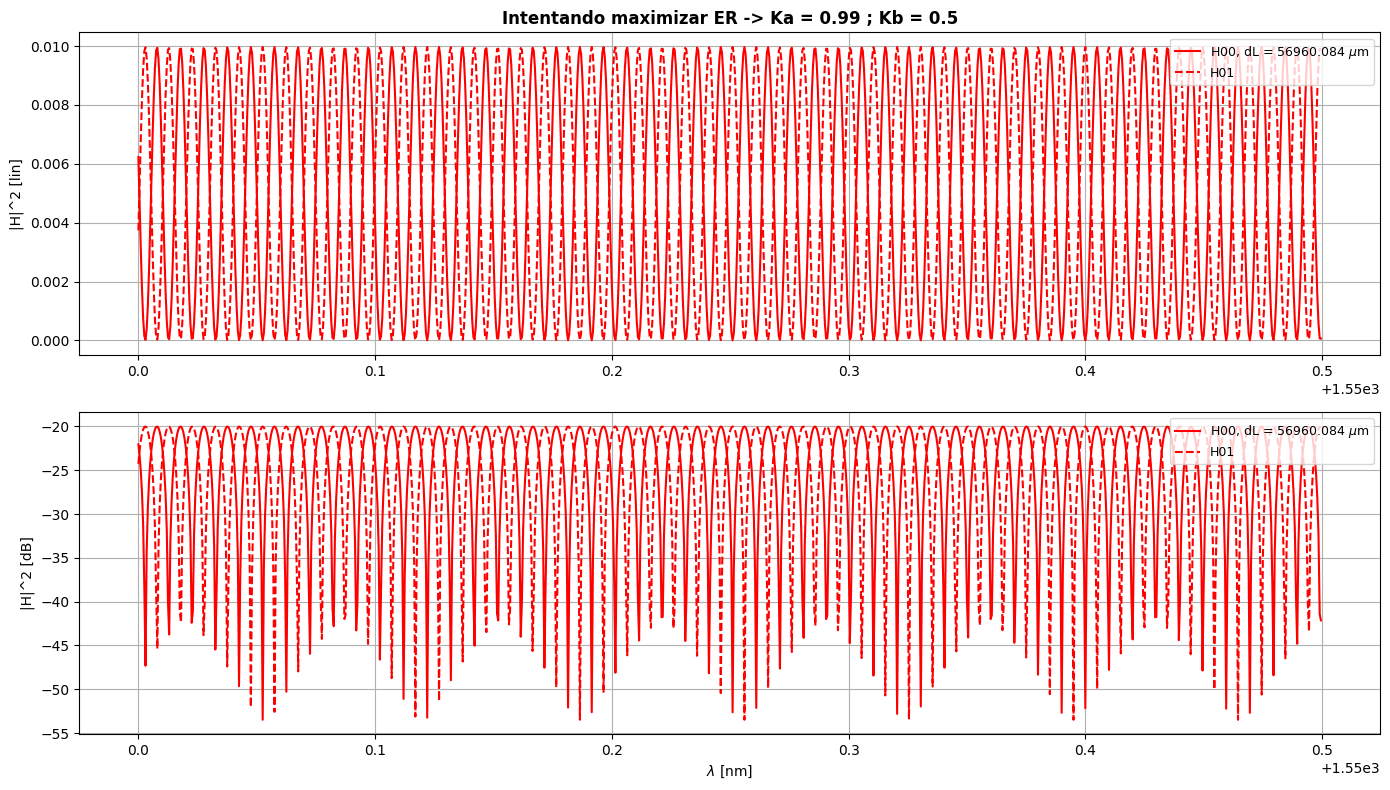

El ER del CASO EXTRA es: 33.47 dB


In [11]:
# 1. Vector de longitudes de onda en el rango de: [1550-1550.5] nm (con saltos de 0.0000005)
wvl = jnp.arange(1.55, 1.5505, 0.0000005)

l_base = 1000.0
delta_l = l_base + 55960.0840224255 

config_wvg_comun = {
    "neff": 2.38,
    "ng": 4.25,
    "D": 0,
    "loss": 4e-4 # 4 dB/cm en dB/um
}

# Simular MZI para todo el vector wvl
mzi_sim = mzi(
    wl = wvl, 
    coup_E = {"coupling": 0.9943},
    coup_W = {"coupling": 0.5},
    wvg_S = {"length": l_base, **config_wvg_comun}, 
    wvg_N = {"length": l_base+delta_l, **config_wvg_comun}
)


H00_sim = mzi_sim["in0", "out0"]
H01_sim = mzi_sim["in0", "out1"]
H00_dB_sim = 20.0*jnp.log10(np.abs(H00_sim) + 1e-12)
H01_dB_sim = 20.0*jnp.log10(np.abs(H01_sim) + 1e-12)

# Crear figura con 2 subgráficas (2 filas x 1 columnas)
fig, ax = plt.subplots(2, 1, figsize=(14, 8))

# ------- Fila 0: Escala lineal ------- #
ax[0].plot(wvl * 1e3, np.abs(H00_sim)**2, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
ax[0].plot(wvl * 1e3, np.abs(H01_sim)**2, linestyle="--", color='red', label=f"H01")
ax[0].set_title("Intentando maximizar ER -> Ka = 0.99 ; Kb = 0.5", fontweight='bold')
ax[0].set_ylabel("|H|^2 [lin]")


# ------- Fila 1: En dB ------- #
ax[1].plot(wvl * 1e3, H00_dB_sim, linestyle="-", color='red', label=f"H00, dL = {delta_l:.3f} $\mu$m")
ax[1].plot(wvl * 1e3, H01_dB_sim, linestyle="--", color='red', label=f"H01")
ax[1].set_ylabel("|H|^2 [dB]")
ax[1].set_xlabel("$\lambda$ [nm]")

# Formato común para todas las gráficas
for i in range(2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()


H00_dB_numpy = np.array(H00_dB_sim)

ER = np.max(H00_dB_numpy) - np.min(H00_dB_numpy)
print(f"El ER del CASO EXTRA es: {ER:.2f} dB")

## LO.4. Ring Resonators.

### 1.1. Ring Resonator Circuit Models

We can implement two different variations for the Ring Resonator. The simple ring that consist of a coupler connected with a waveguide (ring_ap), and the double bus ring that needs an extra coupler and the corresponding waveguides to make connections between them (ring_2bus): 

<img src="rings.png" alt="mzi circuit" width="600">


#### 1.1.1. Ring coupled to a single waveguide

We define one circuit per design variation. 

In [12]:
ring_ap, info = sax.circuit(
    netlist={
        "instances": {
            "coup": "coupler",
            "wvg_ring": "waveguide",
        },
        "connections": {
            "coup,out1": "wvg_ring,in0",
            "wvg_ring,out0": "coup,in1",
        },
        "ports": {
            "in0": "coup,in0",
            "out0": "coup,out0"
        },
    },
    models={
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

Then we can test the circuit to check the functionality

Text(0, 0.5, '|H|^2 [dB]')

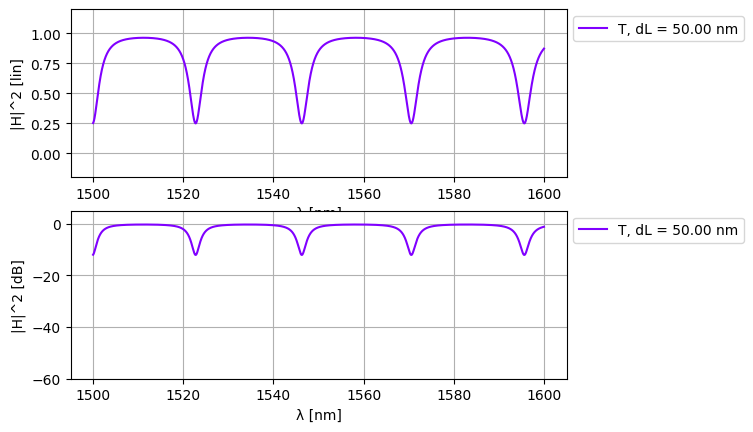

In [13]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([50,]) 

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Here we instantiate the ring resonator with the desired ring length
    # Update this line if you desire to simulate different losses or coupling coefficients
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": delta_l, "loss": 0.02}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

#### 1.1.2. Ring coupled to two waveguides

For this design variation, the ring perimeter is divided into two straight sections that connect both couplers

In [14]:
ring_2bus, info = sax.circuit(
    netlist={
        "instances": {
            "wvg_S_in": "waveguide",
            "wvg_S_out": "waveguide",
            "coup_S": "coupler",
            "wvg_ring_E": "waveguide",
            "wvg_ring_W": "waveguide",
            "coup_N": "coupler",
            "wvg_N_in": "waveguide",
            "wvg_N_out": "waveguide",
        },
        "connections": {
            "wvg_S_in,out0": "coup_S,in0",
            "coup_S,out0": "wvg_S_out,in0",
            "coup_S,out1": "wvg_ring_E,in0",
            "wvg_ring_E,out0": "coup_N,in1",
            "coup_N,out1": "wvg_ring_W,in0",
            "wvg_ring_W,out0": "coup_S,in1",
            "wvg_N_in,out0": "coup_N,in0",
            "coup_N,out0": "wvg_N_out,in0",
        },
        "ports": {
            "in0": "wvg_S_in,in0",
            "out0": "wvg_S_out,out0",
            "in1": "wvg_N_in,in0",
            "out1": "wvg_N_out,out0",
        },
    },
    models= {
        "coupler": coupler,
        "waveguide": waveguide,
    },
)

Test the circuit to check the functionality

Text(0, 0.5, '|H|^2 [dB]')

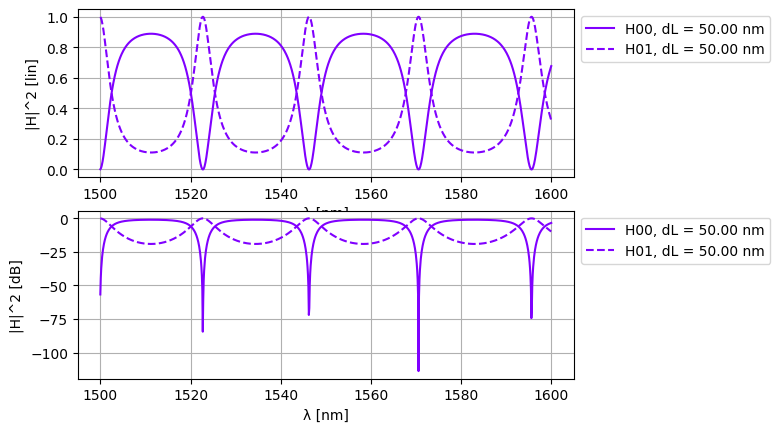

In [15]:
wl = jnp.linspace(1.50, 1.60, 1000)

delta_l_v = np.array([50,]) 

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l, "loss": 2.0}, coup_N={"coupling": 0.0})
    ring_2bus_test = ring_2bus(wl=wl, wvg_ring_E={"length": 0.5*delta_l}, wvg_ring_W={"length": 0.5*delta_l})
    H00 = ring_2bus_test["in0", "out0"]
    H01 = ring_2bus_test["in0", "out1"]

    H00_dB = 20.0*jnp.log10(np.abs(H00) ** 2)
    H01_dB = 20.0*jnp.log10(np.abs(H01) ** 2)

    ax[0].plot(wl * 1e3, np.abs(H00)**2, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[0].plot(wl * 1e3, np.abs(H01)**2, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, H00_dB, linestyle="-", color=color[i], label=f"H00, dL = {delta_l:.2f} nm")
    ax[1].plot(wl * 1e3, H01_dB, linestyle="--", color=color[i], label=f"H01, dL = {delta_l:.2f} nm")

for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")


The resulting interference pattern again exhibits a periodic behavior. We define again the **free spectral range** (FSR), which should satisfy in this case the relationship:

$$
\Delta\lambda_{\mathrm{FSR}}
= \frac{\lambda^{2}}{n_g(\lambda)\,L_r}
$$

Where $L_r$ is the ring perimeter. Note that in our circuit model, we neglect the length of the coupler, so the perimeter is defined by the length of the waveguide sections.

#### **HINT**

You can perform parametric variations using the codes provided by us, for instance, check this casi in which we performed a loss sweep. 

Text(0, 0.5, '|H|^2 [dB]')

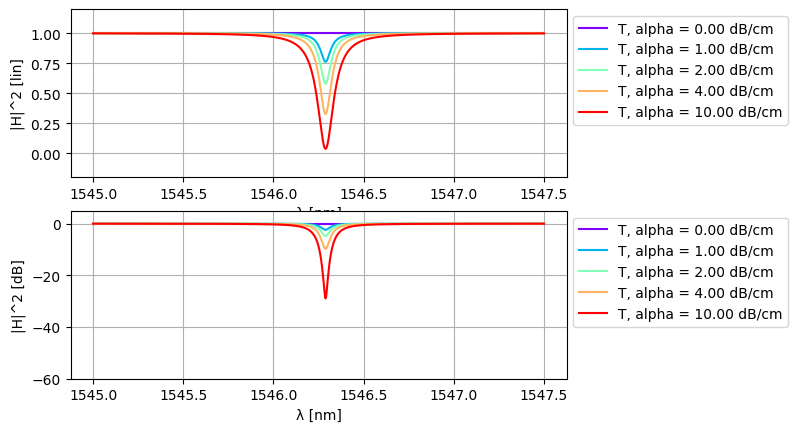

In [16]:
# We change the wavelength range to "zoom in" into a resonance
wl = jnp.linspace(1.545, 1.5475, 1000)

# Now we perform a loss sweep
loss_dBum = 1e-4*np.array([0,1,2,4,10])

n_curves = np.shape(loss_dBum)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

ring_perimeter = 75.0
coupling = 0.025

fig, ax = plt.subplots(2,1)
#Update the variable you enumarate below
for i, loss in enumerate(loss_dBum):
    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": ring_perimeter, "loss": loss}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

Now use this code section to obtain the results of LOs4, 5, and 6.

## LO.4. Single ring Resonator


Text(0, 0.5, '|H|^2 [dB]')

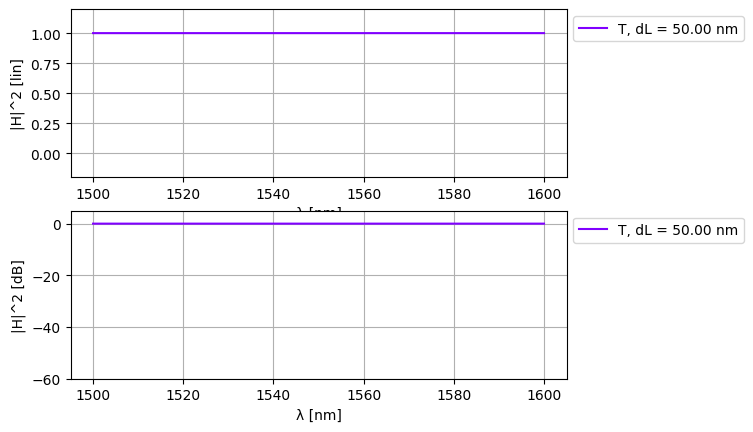

In [17]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([50,]) 

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Here we instantiate the ring resonator with the desired ring length
    # Update this line if you desire to simulate different losses or coupling coefficients
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": delta_l, "loss": 0}, coup={"coupling": coupling}) #el caso más simple tendría pérdidas de 0dB
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")

## LO.5. Single Ring Resonator for a FSR = 15 nm

El ER de este ejercicio es: 20.24 dB


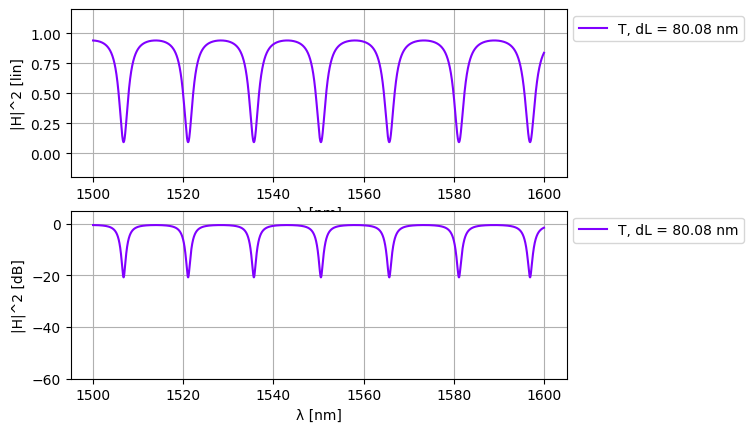

In [18]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([80.08,])  # L_r calculada según expresiones teóricas

# Coupling coefficient of the input/output coupler
coupling = 0.5

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Here we instantiate the ring resonator with the desired ring length
    # Update this line if you desire to simulate different losses or coupling coefficients
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": delta_l, "loss": 0.02}, coup={"coupling": coupling}) #para que oscile las pérdidas deben ser > 0
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")


T_dB_numpy = np.array(T_dB)

ER = np.max(T_dB_numpy) - np.min(T_dB_numpy)
print(f"El ER de este ejercicio es: {ER:.2f} dB")

Intentando conseguir acoplamiento crítico (Maxima ER)

El ER de este ejercicio es: 118.49 dB


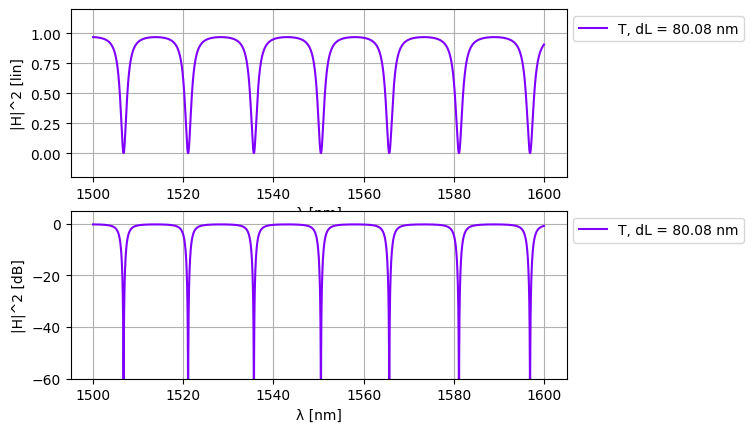

In [19]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Length value to simulate. This is the length of the ring waveguide
delta_l_v = np.array([80.08,])  # L_r calculada según expresiones teóricas

# Coupling coefficient of the input/output coupler
coupling = 0.308 #K = 1 - a^2 donde a = 10^[(loss*L)/20]

n_curves = np.shape(delta_l_v)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

fig, ax = plt.subplots(2,1)
for i, delta_l in enumerate(delta_l_v):
    # Here we instantiate the ring resonator with the desired ring length
    # Update this line if you desire to simulate different losses or coupling coefficients
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": delta_l, "loss": 0.02}, coup={"coupling": coupling}) #para que oscile las pérdidas deben ser > 0
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax[0].plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

    ax[1].plot(wl * 1e3, T_dB, linestyle="-", color=color[i], label=f"T, dL = {delta_l:.2f} nm")

ax[0].set_ylim([-0.2,1.2])
for i in range(0,2):
    ax[i].grid(visible=True)
    ax[i].legend(fontsize=8)
    ax[i].set_xlabel("λ [nm]")
    ax[i].legend(loc='upper left', bbox_to_anchor=(1, 1))
ax[1].set_ylim([-60,5])

ax[0].set_ylabel("|H|^2 [lin]")
ax[1].set_ylabel("|H|^2 [dB]")


T_dB_numpy = np.array(T_dB)

ER = np.max(T_dB_numpy) - np.min(T_dB_numpy)
print(f"El ER de este ejercicio es: {ER:.2f} dB")

## LO.6. More of Single Ring resonators

### LO.6.a. Effect of K

Text(0, 0.5, '|H|^2 [lin]')

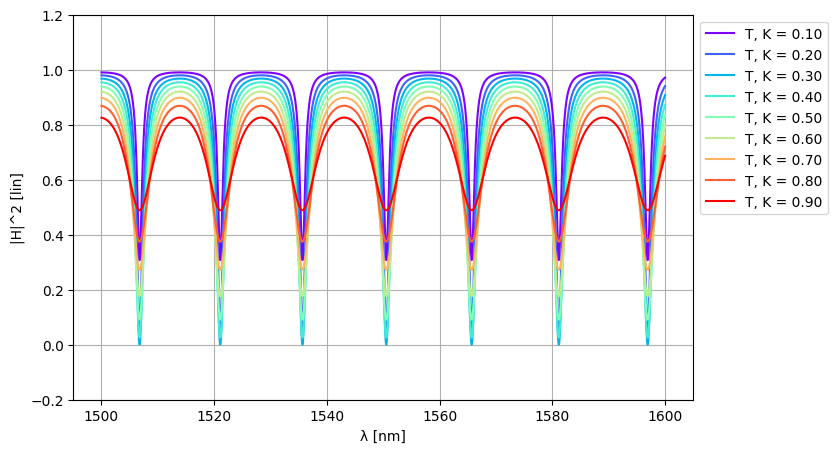

In [20]:
# Wavelengths to simulate
wl = jnp.linspace(1.50, 1.60, 10000)

# Now we perform a K sweep
K_array = jnp.arange(0.1, 1, 0.1) #tal y como pide el ejercicio, de 0.1 a 0.9 con saltos de 0.1 

n_curves = np.shape(K_array)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

ring_perimeter = 80.08 #utilizamos el perímetro calculado en el ejercicio anterior. Decisión nuestra

fig, ax = plt.subplots(figsize=(8, 5))
#Update the variable you enumarate below
for i, K_value in enumerate(K_array):
    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": ring_perimeter, "loss": 0.02}, coup={"coupling": K_value})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax.plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, K = {K_value:.2f}")

ax.set_ylim([-0.2,1.2])

ax.grid(visible=True)
ax.legend(fontsize=8)
ax.set_xlabel("λ [nm]")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

ax.set_ylabel("|H|^2 [lin]")

### LO.6.b. Effect of loss

Text(0, 0.5, '|H|^2 [lin]')

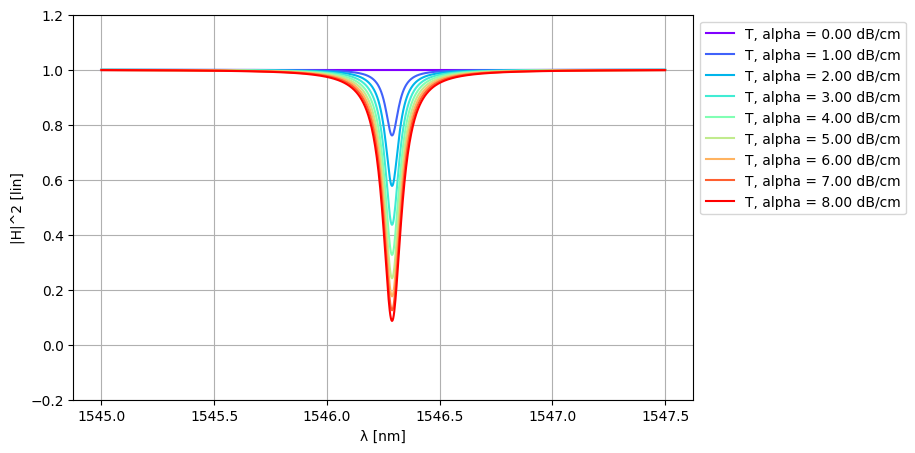

In [21]:
# We change the wavelength range to "zoom in" into a resonance
wl = jnp.linspace(1.545, 1.5475, 1000)

# Now we perform a loss sweep
loss_dBum = 1e-4*(jnp.arange(0, 9, 1)) # de 0 a 8 dB/cm

n_curves = np.shape(loss_dBum)[0]
color = cm.rainbow(np.linspace(0, 1, n_curves))

ring_perimeter = 75.0
coupling = 0.025

fig, ax = plt.subplots(figsize=(8, 5))
#Update the variable you enumarate below
for i, loss in enumerate(loss_dBum):
    # Link the variable you want to sweep in the line below
    ring_ap_test = ring_ap(wl=wl, wvg_ring={"length": ring_perimeter, "loss": loss}, coup={"coupling": coupling})
    T = ring_ap_test["in0", "out0"]

    T_dB = 20.0*jnp.log10(np.abs(T) ** 2)

    ax.plot(wl * 1e3, np.abs(T)**2, linestyle="-", color=color[i], label=f"T, alpha = {1e4*loss:.2f} dB/cm")

ax.set_ylim([-0.2,1.2])

ax.grid(visible=True)
ax.legend(fontsize=8)
ax.set_xlabel("λ [nm]")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

ax.set_ylabel("|H|^2 [lin]")